In [32]:
import polars as pl
import seaborn as sns
import numpy as np

In [ ]:
dpl = pl.read_csv(
    "/Users/SML161/eagle/datasets/snapshotUSA_2019-2023/ssusa_finaldeployments.csv"
)
sequences = pl.read_csv(
    "/Users/SML161/eagle/datasets/snapshotUSA_2019-2023/ssusa_finalsequences.csv"
)

In [ ]:
sp_counts_per_dpl = sequences.group_by(["Deployment_ID", "Common_Name"]).len()
unique_sp_per_dpl = sequences.group_by("Deployment_ID").agg(
    pl.col("Common_Name").n_unique().alias("unique_species_count")
)

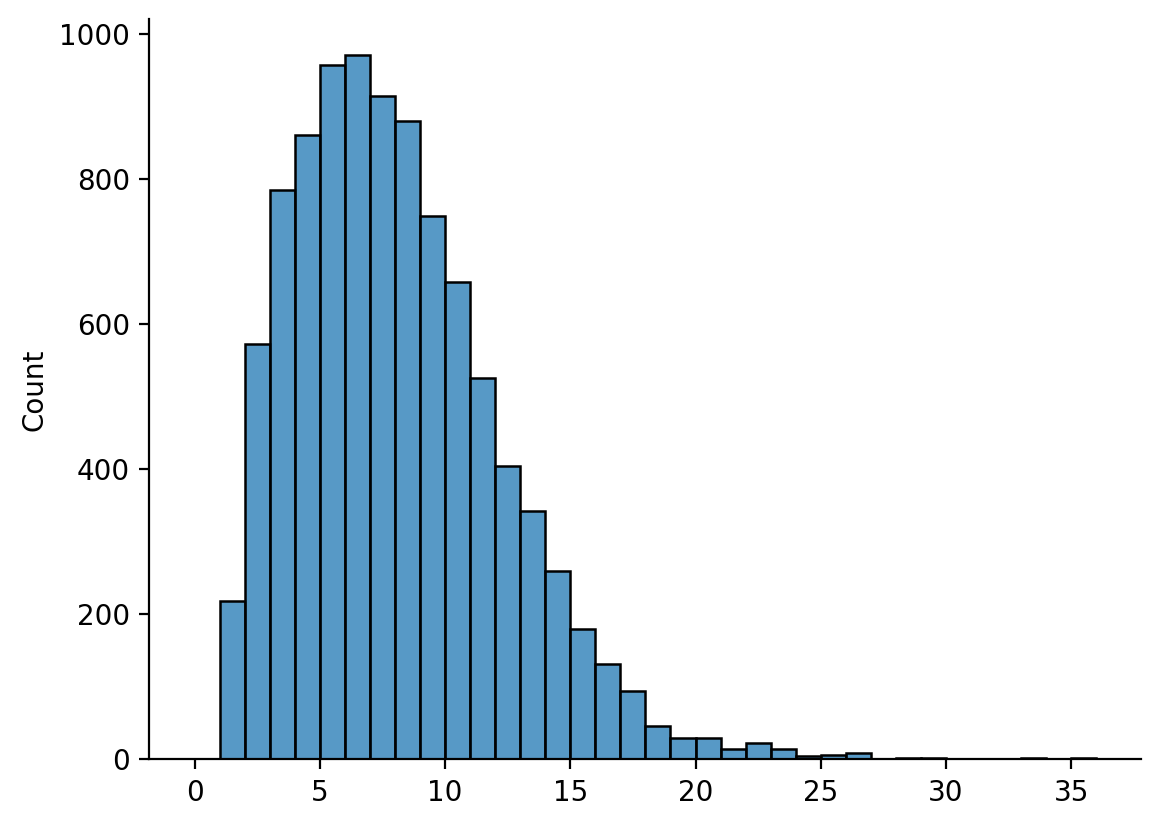

In [37]:
sns.histplot(
    unique_sp_per_dpl["unique_species_count"],
    bins=np.arange(0, unique_sp_per_dpl["unique_species_count"].max() + 1, 1),
)
sns.despine()
# title="Sp per dpl"